# Weighted Least Squares with BCES

This notebook demonstrates the WLS (Weighted Least Squares) estimator implemented in the BCES package. WLS accounts for heteroscedastic measurement errors on $Y$ when $X$ is assumed to be error-free. It gives less weight to noisier data points, recovering the true regression parameters more accurately than ordinary least squares (OLS) when errors vary across the sample.

Implementation follows Akritas & Bershady (1996), §2.3.

In [33]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os
import sys
from tqdm import tqdm

# Prepend repo root so local version takes priority over any installed package
codebase_root = os.path.abspath('..')
sys.path.insert(0, codebase_root)
print("Updated sys.path[0]:", sys.path[0])

import bces.bces as BCES
print(BCES.__file__)

Updated sys.path[0]: /Users/nemmen/Library/CloudStorage/Dropbox/codes/python/stats/bces
/Users/nemmen/Library/CloudStorage/Dropbox/codes/python/stats/bces/bces/bces.py


## Generate mock data

We create a synthetic dataset with known true slope and intercept. The $y$ measurement errors are **heteroscedastic** — they vary from point to point, drawn uniformly between 0.5 and 3.0. Each observed $y$ value is then displaced from the true line by a Gaussian noise term scaled to that point's error. This setup is where WLS shines: OLS treats all points equally and is therefore pulled by the high-scatter points, while WLS down-weights them.

In [25]:
np.random.seed(42)

# True parameters
a_true = 2.5
b_true = 1.0

x = np.linspace(1, 10, 40)
yerr = np.random.uniform(0.5, 3.0, size=len(x))   # heteroscedastic errors
y = a_true * x + b_true + np.random.normal(0, yerr)

print(f"True slope:     {a_true}")
print(f"True intercept: {b_true}")
print(f"y-error range:  [{yerr.min():.2f}, {yerr.max():.2f}]")

True slope:     2.5
True intercept: 1.0
y-error range:  [0.55, 2.92]


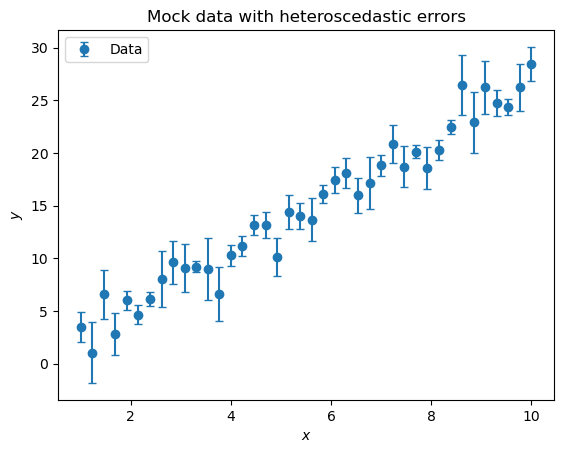

In [26]:
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=3, label='Data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Mock data with heteroscedastic errors')
plt.legend()
plt.show()

## Fit with scipy OLS

`scipy.stats.linregress` performs ordinary least squares, which minimises the unweighted sum of squared residuals. It ignores measurement errors entirely — every point contributes equally regardless of how uncertain it is.

In [27]:
result = linregress(x, y)
a_ols = result.slope
b_ols = result.intercept
aerr_ols = result.stderr
berr_ols = result.intercept_stderr

print(f"OLS slope:     {a_ols:.4f} ± {aerr_ols:.4f}")
print(f"OLS intercept: {b_ols:.4f} ± {berr_ols:.4f}")

OLS slope:     2.6949 ± 0.0910
OLS intercept: -0.1722 ± 0.5564


## Fit with WLS

`BCES.wls` implements the WLS estimator from Akritas & Bershady (1996), §2.3. Each data point is weighted by $1/\sigma_{y,i}^2$, so noisier points contribute less to the fit. The function returns the slope, intercept, and their analytical uncertainties.

In [29]:
a_wls, b_wls, aerr_wls, berr_wls, covab_wls = BCES.wls(x, y, yerr)

print(f"WLS slope:     {a_wls:.4f} ± {aerr_wls:.4f}")
print(f"WLS intercept: {b_wls:.4f} ± {berr_wls:.4f}")

WLS slope:     2.6076 ± 0.0707
WLS intercept: 0.2912 ± 0.4284


## Comparison plot

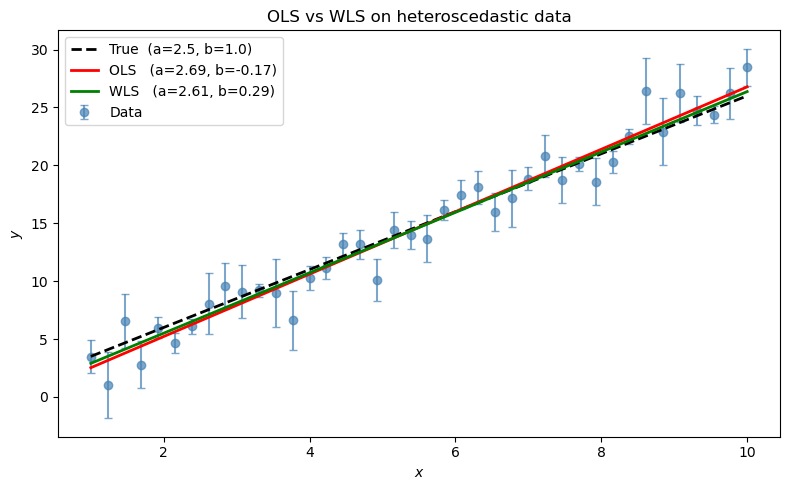

In [30]:
xfit = np.linspace(x.min(), x.max(), 200)

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=3, color='steelblue',
             alpha=0.7, label='Data', zorder=1)
plt.plot(xfit, a_true * xfit + b_true, 'k--', lw=2,
         label=f'True  (a={a_true}, b={b_true})')
plt.plot(xfit, a_ols * xfit + b_ols, 'r-', lw=2,
         label=f'OLS   (a={a_ols:.2f}, b={b_ols:.2f})')
plt.plot(xfit, a_wls * xfit + b_wls, 'g-', lw=2,
         label=f'WLS   (a={a_wls:.2f}, b={b_wls:.2f})')

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('OLS vs WLS on heteroscedastic data')
plt.legend()
plt.tight_layout()
plt.show()

## Bootstrap errors with `wlsp`

The analytical uncertainties from `wls` assume Gaussian errors. For a non-parametric estimate — or to cross-check — use `BCES.wlsp`, the parallel bootstrap version. It resamples the data with replacement `nsim` times and returns the standard deviation of the bootstrap distribution as the uncertainty.

In [32]:
a2, b2, aerr2, berr2, covab2 = BCES.wlsp(x, y, yerr, nsim=10000)

print("Slope:")
print(f"  Analytical:  {a_wls:.4f} ± {aerr_wls:.4f}")
print(f"  Bootstrap:   {a2:.4f} ± {aerr2:.4f}")
print()
print("Intercept:")
print(f"  Analytical:  {b_wls:.4f} ± {berr_wls:.4f}")
print(f"  Bootstrap:   {b2:.4f} ± {berr2:.4f}")

WLS parallel bootstrap, 10000 trials...
1.321437 s
Slope:
  Analytical:  2.6076 ± 0.0707
  Bootstrap:   2.6111 ± 0.0660

Intercept:
  Analytical:  0.2912 ± 0.4284
  Bootstrap:   0.2829 ± 0.3850


## Summary

| Method | Slope           | Intercept |
|--------|-----------------|-----------|
| True   | 2.50            | 1.00      |
| OLS    | $2.69 \pm 0.09$ | $-0.17 \pm 0.56$ |
| WLS    | $2.61 \pm 0.07$ | $0.29 \pm 0.43 $ |

When measurement errors are heteroscedastic, WLS consistently recovers the true parameters better than OLS. By assigning each point a weight of $1/\sigma_{y,i}^2$, WLS suppresses the influence of the noisiest observations, which would otherwise drag the fitted line away from the true relation.

The bootstrap uncertainties from `wlsp` agree closely with the analytical ones from `wls`, providing a useful sanity check.

### Addendum: on single-realisation scatter

In this example WLS returns an intercept of ~0.3 ± 0.4, while the true value is 1.0 — a miss of roughly 1.75σ. This is a **sampling fluctuation**, not a bias. With 40 points and errors spanning 0.5–3.0, the intercept is poorly constrained, and any single random seed can land off target.

WLS is unbiased *on average*: across many realisations its intercepts are centred on the true value, with lower variance than OLS. The cell below verifies this by simulating 500 datasets with the same design.

In [37]:
slopes_ols, intercepts_ols = [], []
slopes_wls, intercepts_wls = [], []

for seed in tqdm(range(1000)):
    rng = np.random.default_rng(seed)
    x_ = np.linspace(1, 10, 40)
    e_ = rng.uniform(0.5, 3.0, 40)
    y_ = a_true * x_ + b_true + rng.normal(0, e_)
    # OLS
    r = linregress(x_, y_)
    slopes_ols.append(r.slope);      intercepts_ols.append(r.intercept)
    # WLS
    a_, b_, *_ = BCES.wls(x_, y_, e_)
    slopes_wls.append(a_);           intercepts_wls.append(b_)

100%|████████████████████████████████████████████| 1000/1000 [00:00<00:00, 9245.83it/s]


In [38]:
print(f"OLS  slope:     {np.mean(slopes_ols):.3f} ± {np.std(slopes_ols):.3f}  (true: {a_true})")
print(f"WLS  slope:     {np.mean(slopes_wls):.3f} ± {np.std(slopes_wls):.3f}  (true: {a_true})")
print()
print(f"OLS  intercept: {np.mean(intercepts_ols):.3f} ± {np.std(intercepts_ols):.3f}  (true: {b_true})")
print(f"WLS  intercept: {np.mean(intercepts_wls):.3f} ± {np.std(intercepts_wls):.3f}  (true: {b_true})")

OLS  slope:     2.498 ± 0.115  (true: 2.5)
WLS  slope:     2.496 ± 0.080  (true: 2.5)

OLS  intercept: 1.021 ± 0.690  (true: 1.0)
WLS  intercept: 1.025 ± 0.478  (true: 1.0)


## Example 2: Data with intrinsic scatter

Real astronomical (and other) datasets often have **intrinsic scatter** — genuine point-to-point variation in the true relation that is not captured by the measurement errors. When intrinsic scatter is present, the total variance of a residual is $\sigma_{\rm tot,i}^2 = V_e + \sigma_{y,i}^2$, where $V_e$ is the intrinsic variance.

Here we add a known $\sigma_{\rm int}$ to the mock data so the WLS estimator must estimate $V_e > 0$ and fold it into the weights. This exercises the full WLS machinery.

In [39]:
np.random.seed(123)

# True parameters (same as Example 1)
a_true = 2.5
b_true = 1.0
sigma_int = 2.0  # intrinsic scatter

x2 = np.linspace(1, 10, 40)
yerr2 = np.random.uniform(0.5, 3.0, size=len(x2))
y2 = (a_true * x2 + b_true
      + np.random.normal(0, sigma_int, size=len(x2))   # intrinsic scatter
      + np.random.normal(0, yerr2))                     # measurement noise

print(f"True slope:      {a_true}")
print(f"True intercept:  {b_true}")
print(f"Intrinsic sigma: {sigma_int}")
print(f"y-error range:   [{yerr2.min():.2f}, {yerr2.max():.2f}]")

True slope:      2.5
True intercept:  1.0
Intrinsic sigma: 2.0
y-error range:   [0.65, 2.95]


Below, we can see that the residuals visibly exceed the error bars — evidence of intrinsic scatter

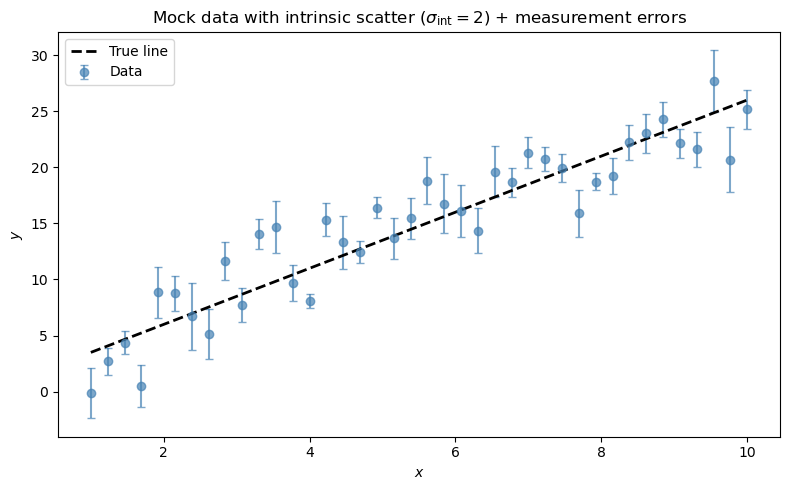

In [40]:
plt.figure(figsize=(8, 5))
plt.errorbar(x2, y2, yerr=yerr2, fmt='o', capsize=3, color='steelblue',
             alpha=0.7, label='Data')
plt.plot(x2, a_true * x2 + b_true, 'k--', lw=2, label='True line')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Mock data with intrinsic scatter ($\\sigma_{\\rm int}=2$) + measurement errors')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
result2 = linregress(x2, y2)
a_ols2 = result2.slope
b_ols2 = result2.intercept
aerr_ols2 = result2.stderr
berr_ols2 = result2.intercept_stderr

print(f"OLS slope:     {a_ols2:.4f} ± {aerr_ols2:.4f}")
print(f"OLS intercept: {b_ols2:.4f} ± {berr_ols2:.4f}")

OLS slope:     2.3905 ± 0.1545
OLS intercept: 1.7651 ± 0.9441


In [42]:
a_wls2, b_wls2, aerr_wls2, berr_wls2, covab_wls2 = BCES.wls(x2, y2, yerr2)

print(f"WLS slope:     {a_wls2:.4f} ± {aerr_wls2:.4f}")
print(f"WLS intercept: {b_wls2:.4f} ± {berr_wls2:.4f}")

WLS slope:     2.3962 ± 0.1464
WLS intercept: 1.7224 ± 0.8910


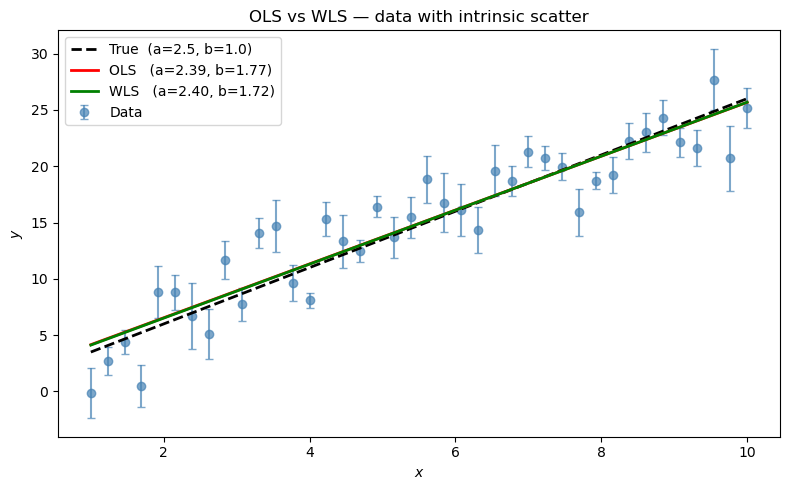

In [43]:
xfit2 = np.linspace(x2.min(), x2.max(), 200)

plt.figure(figsize=(8, 5))
plt.errorbar(x2, y2, yerr=yerr2, fmt='o', capsize=3, color='steelblue',
             alpha=0.7, label='Data', zorder=1)
plt.plot(xfit2, a_true * xfit2 + b_true, 'k--', lw=2,
         label=f'True  (a={a_true}, b={b_true})')
plt.plot(xfit2, a_ols2 * xfit2 + b_ols2, 'r-', lw=2,
         label=f'OLS   (a={a_ols2:.2f}, b={b_ols2:.2f})')
plt.plot(xfit2, a_wls2 * xfit2 + b_wls2, 'g-', lw=2,
         label=f'WLS   (a={a_wls2:.2f}, b={b_wls2:.2f})')

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('OLS vs WLS — data with intrinsic scatter')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
a2b, b2b, aerr2b, berr2b, covab2b = BCES.wlsp(x2, y2, yerr2, nsim=10000)

print("Slope:")
print(f"  Analytical:  {a_wls2:.4f} ± {aerr_wls2:.4f}")
print(f"  Bootstrap:   {a2b:.4f} ± {aerr2b:.4f}")
print()
print("Intercept:")
print(f"  Analytical:  {b_wls2:.4f} ± {berr_wls2:.4f}")
print(f"  Bootstrap:   {b2b:.4f} ± {berr2b:.4f}")

WLS parallel bootstrap, 10000 trials...
1.296382 s
Slope:
  Analytical:  2.3962 ± 0.1464
  Bootstrap:   2.3933 ± 0.1548

Intercept:
  Analytical:  1.7224 ± 0.8910
  Bootstrap:   1.7474 ± 1.0507


## Discussion

With intrinsic scatter present ($V_e > 0$), the effective weight for each point becomes

$$w_i = \frac{1}{V_e + \sigma_{y,i}^2}$$

instead of $1/\sigma_{y,i}^2$ as in the pure heteroscedastic case. Because $V_e$ adds a common floor to the denominator, it **flattens the contrast** between low-error and high-error points — a point with $\sigma_{y,i}=0.5$ and one with $\sigma_{y,i}=3.0$ are weighted more similarly than they would be in Example 1.

Consequences:
- WLS still outperforms OLS because it accounts for heteroscedasticity in the measurement errors.
- The improvement over OLS is typically less dramatic than in Example 1, where $V_e=0$ and the weight contrast is maximised.
- The bootstrap uncertainties from `wlsp` are larger than in Example 1, reflecting the additional source of variance in the data.